In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
try:
  connect = sqlite3.connect('data/checking-logs.sqlite')
  print('OK. Connected to sqlite')

except sqlite3.Error as error:
  print('Error with connection:', error)

OK. Connected to sqlite


In [3]:
query = '''
SELECT uid, timestamp
FROM checker
WHERE uid LIKE 'user_%'
'''
commits = pd.io.sql.read_sql(query, connect, parse_dates=['timestamp'])
commits

,uid,timestamp
0,user_4,2020-04-17 05:19:02.744528
1,user_4,2020-04-17 05:22:35.249331
2,user_4,2020-04-17 05:22:45.549397
3,user_4,2020-04-17 05:34:14.691200
4,user_4,2020-04-17 05:34:24.422370
...,...,...
3202,user_1,2020-05-21 20:19:06.872761
3203,user_1,2020-05-21 20:22:41.785725
3204,user_1,2020-05-21 20:22:41.877806
3205,user_1,2020-05-21 20:37:00.129678


In [4]:
commits['weekday'] = commits['timestamp'].dt.weekday
commits['hour'] = commits.timestamp.dt.hour
commits['type'] = commits['weekday'].apply(
    lambda x:'workday' if x < 5 else 'weekend'
)
commits

,uid,timestamp,weekday,hour,type
0,user_4,2020-04-17 05:19:02.744528,4,5,workday
1,user_4,2020-04-17 05:22:35.249331,4,5,workday
2,user_4,2020-04-17 05:22:45.549397,4,5,workday
3,user_4,2020-04-17 05:34:14.691200,4,5,workday
4,user_4,2020-04-17 05:34:24.422370,4,5,workday
...,...,...,...,...,...
3202,user_1,2020-05-21 20:19:06.872761,3,20,workday
3203,user_1,2020-05-21 20:22:41.785725,3,20,workday
3204,user_1,2020-05-21 20:22:41.877806,3,20,workday
3205,user_1,2020-05-21 20:37:00.129678,3,20,workday


In [5]:
working_day = commits[commits['type']=='workday']['hour'].reset_index()
working_day

,index,hour
0,0,5
1,1,5
2,2,5
3,3,5
4,4,5
...,...,...
2032,3202,20
2033,3203,20
2034,3204,20
2035,3205,20


In [6]:
weekend = commits[commits['type'] ==
                  'weekend']['hour'].reset_index()
weekend

,index,hour
0,23,7
1,24,13
2,25,13
3,26,13
4,27,13
...,...,...
1165,3088,22
1166,3089,22
1167,3090,22
1168,3091,22


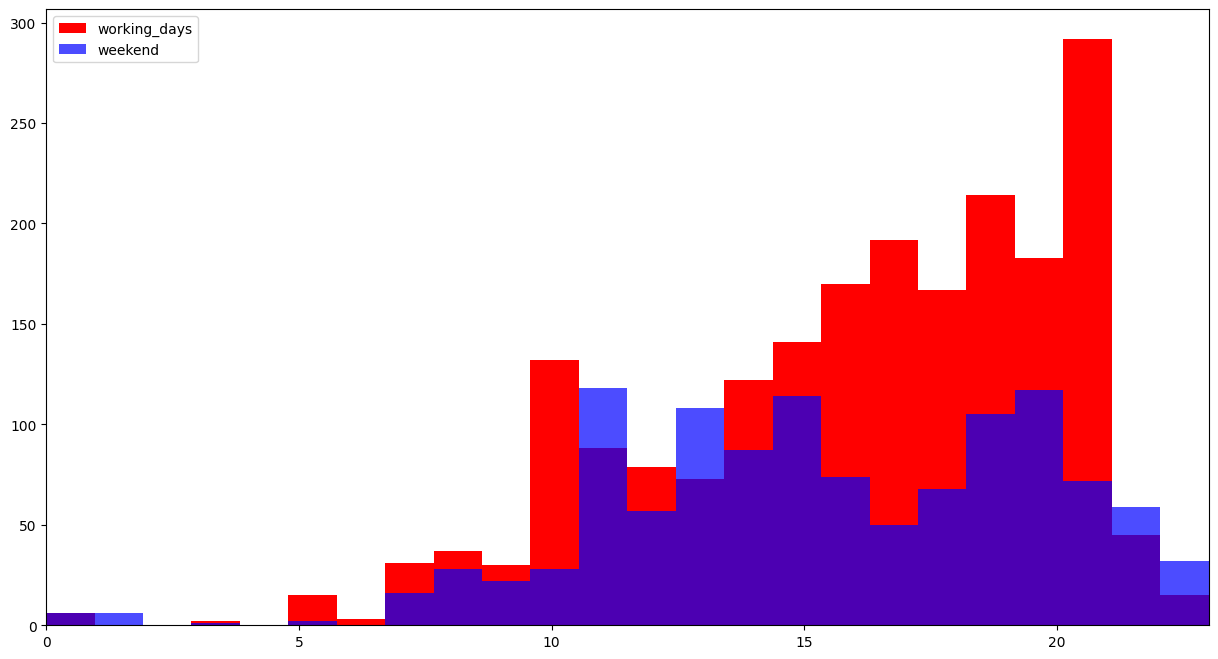

In [7]:
fig, ax = plt.subplots(figsize=(15, 8))
ax.hist(working_day['hour'],
        bins=24,
        label='working_days',
        color='r')
ax.hist(weekend['hour'],
        bins=24,
        label='weekend',
        color='b',
        alpha=0.7)
ax.set_xlim(0, 23)
ax.legend(loc='upper left', fontsize='10')
plt.show()

In [42]:
commits_group = commits.groupby(['type', 'hour']).count()['uid'].reset_index()
pivot_table = pd.pivot_table(commits_group,
                             values='uid',
                             index='hour',
                             columns='type')
table_w_w = pivot_table[pivot_table['weekend'] > pivot_table['workday']]
table_w_w

type,weekend,workday
hour,,
11,118.0,88.0
13,108.0,73.0
22,59.0,45.0
23,32.0,15.0


In [46]:
### Ответ. Часы, когда общее количество коммитов было выше в выходные, чем в 
# рабочие дни: 11, 13, 22, 23

In [47]:
connect.close()